### model training without handling class imbalance issue

Class order used by LabelEncoder: ['High', 'Low', 'Moderate', 'Severe']
Accuracy: 0.9714


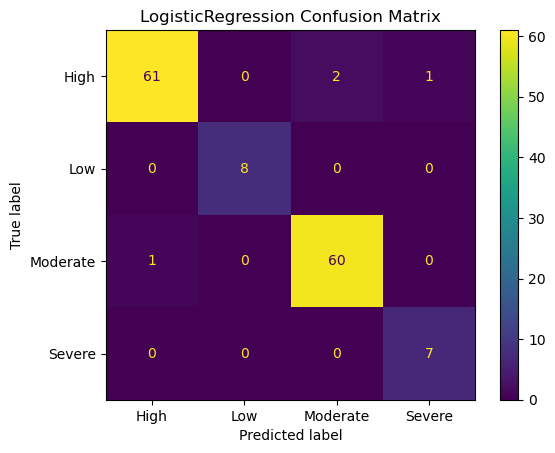

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import joblib

# Step 1: Load labeled data
df = pd.read_csv('../../data/MentalParameter_labeled.csv')

# Step 2: Define feature columns
features = [
    "Perceived Control",
    "Stress Frequency and Intensity (Weight: 15%)",
    "Emotional Regulation",
    "Physical Symptoms of Stress",
    "Cognitive Stress (Negative Self-Thoughts)",
    "Behavioral Response",
    "Work-Related Stress Factors (Weight: 10%)",
    "Concentration and Productivity (Weight: 10%)",
    "Suicidal Thoughts (Optional, Use with Caution)",
    "Available Time Normalized"
]

# Step 3: Prepare data
X = df[features].fillna(df[features].mean())
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Stress_Level"])

print("Class order used by LabelEncoder:", list(label_encoder.classes_))

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train and evaluate
best_model = None
best_score = 0

model = SVC(probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {score:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title(f"LogisticRegression Confusion Matrix")
plt.show()

if score > best_score:
    best_score = score
    best_model = model

# Step 7: Save best model and encoder
model_save_path = "../../../artifact/mental/MLModel.pkl"
encoder_save_path = "../../../artifact/mental/LabelEncoder.pkl"



### model training after handling class imbalance issue

Class order used by LabelEncoder: ['High', 'Low', 'Moderate', 'Severe']
Balanced class distribution: Counter({2: 315, 1: 315, 0: 315, 3: 315})
Accuracy: 0.9921


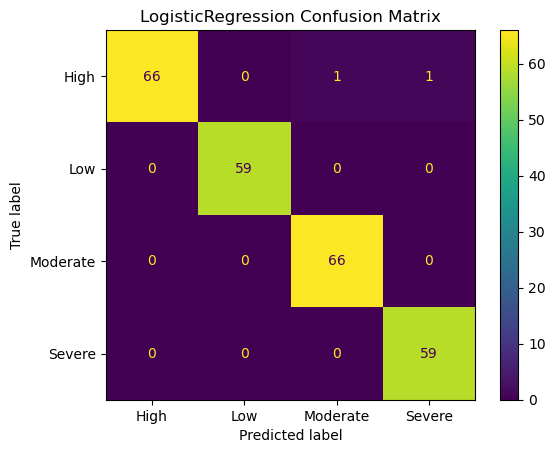


Best model saved to: ../models/MLModel.pkl
LabelEncoder saved to: ../models/LabelEncoder.pkl


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import joblib
from imblearn.over_sampling import SMOTE
from collections import Counter

# Step 1: Load labeled data
df = pd.read_csv('../../data/MentalParameter_labeled.csv')

# Step 2: Define feature columns
features = [
    "Perceived Control",
    "Stress Frequency and Intensity (Weight: 15%)",
    "Emotional Regulation",
    "Physical Symptoms of Stress",
    "Cognitive Stress (Negative Self-Thoughts)",
    "Behavioral Response",
    "Work-Related Stress Factors (Weight: 10%)",
    "Concentration and Productivity (Weight: 10%)",
    "Suicidal Thoughts (Optional, Use with Caution)",
    "Available Time Normalized"
]

# Step 3: Prepare data
X = df[features].fillna(df[features].mean())
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Stress_Level"])

print("Class order used by LabelEncoder:", list(label_encoder.classes_))

# Step 4: Apply SMOTE for class balance
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("Balanced class distribution:", Counter(y_balanced))

# Step 5: Train-test split on balanced data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Step 6: Train and evaluate
model = SVC(probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {score:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("LogisticRegression Confusion Matrix")
plt.show()

# Step 7: Save model and encoder
model_save_path = "../../../artifact/mental/MLModel.pkl"
encoder_save_path = "../../../artifact/mental/LabelEncoder.pkl"

joblib.dump(model, model_save_path)
joblib.dump(label_encoder, encoder_save_path)

print(f"\nBest model saved to: {model_save_path}")
print(f"LabelEncoder saved to: {encoder_save_path}")
